GROUP 8- GENERATING GNN DATASET
ECE 310 - Wireless Communication

In [1]:
import numpy as np
import scipy.signal as sp
import torch
import os
import json
import matplotlib.pyplot as plt

Generate .dat files with EXACT paper parameters from Section V-A1 - FIXED VERSION

In [2]:
def generate_paper_accurate_dat_files():
    # Paper parameters (Section V-A1)
    M = 8                    # 8 receiving antennas
    num_symbols = 100        # 100 modulated symbols per sensing period
    sps = 8                  # 8 samples per symbol
    symbol_rate = 1e6        # 1 MHz symbol rate
    rolloff = 0.5            # Root raised cosine roll-off factor 0.5
    span = 4                 # Filter span of 4 symbols
    correlation_coeff = 0.5  # Correlation between adjacent antennas

    # Requested SNR levels
    snr_levels = [-20,-15,-10,-5,0,5]

    generated_files = []

    for snr_db in snr_levels:
        filename = f"Final_{snr_db}dB.dat"
        print(f"\n Generating {filename}...")

        # Generate data with paper parameters
        iq_samples = generate_paper_accurate_signal(snr_db, M, num_symbols, sps, rolloff, span, correlation_coeff)

        # Save as .dat file
        save_dat_file(filename, iq_samples)

        # Verify the file has proper signals
        verify_signal_quality(filename, snr_db)

        file_size = os.path.getsize(filename) / (1024 * 1024)
        print(f"Saved: {filename} ({file_size:.2f} MB)")
        generated_files.append(filename)

    return generated_files

Generating paper accurate signal

In [10]:
def generate_paper_accurate_signal(snr_db, M, num_symbols, sps, rolloff, span, correlation_coeff):

    N = num_symbols * sps  # Total samples = 800

    # Correlation matrix (paper: ρ=0.5 between adjacent antennas)
    dist_matrix = np.abs(np.arange(M)[:, None] - np.arange(M))
    R = correlation_coeff ** dist_matrix
    L = np.linalg.cholesky(R)

    # Initialize I/Q samples array
    all_iq_samples = []
    samples_per_file = 10000  # Reduced for testing, increase later

    # Generate mixed H1 and H0 samples (like real recording)
    for i in range(samples_per_file):
        # Alternate between H1 and H0
        if i % 2 == 0:
            # H1: Signal + Noise
            iq_samples = generate_h1_signal(snr_db, M, N, L, num_symbols, sps, rolloff, span)
        else:
            # H0: Noise only
            iq_samples = generate_h0_signal(M, N, L)

        all_iq_samples.append(iq_samples)

    # Concatenate and return
    return np.concatenate(all_iq_samples)

Proper Root Raised Cosine filter implementation

In [11]:
def root_raised_cosine(alpha, sps, span):

    delay = span * sps // 2
    t = np.arange(-delay, delay + 1) / sps

    # Initialize filter
    h = np.zeros_like(t)

    for i, t_val in enumerate(t):
        if t_val == 0:
            h[i] = 1.0 - alpha + (4 * alpha / np.pi)
        elif alpha != 0 and abs(4 * alpha * t_val) == 1:
            h[i] = (alpha / np.sqrt(2)) * (
                (1 + 2 / np.pi) * np.sin(np.pi / (4 * alpha)) +
                (1 - 2 / np.pi) * np.cos(np.pi / (4 * alpha))
            )
        else:
            num = np.sin(np.pi * t_val * (1 - alpha)) + 4 * alpha * t_val * np.cos(np.pi * t_val * (1 + alpha))
            den = np.pi * t_val * (1 - (4 * alpha * t_val) ** 2)
            h[i] = num / den

    # Normalize energy
    h = h / np.sqrt(np.sum(h ** 2))
    return h

Generate H1 signal with paper parameters - FIXED VERSION

In [12]:
def generate_h1_signal(snr_db, M, N, L, num_symbols, sps, rolloff, span):

    # Generate QPSK symbols (paper: QPSK modulation)
    symbols = np.random.randint(0, 4, num_symbols)
    qpsk_constellation = [1+1j, -1+1j, -1-1j, 1-1j]
    qpsk_symbols = np.array([qpsk_constellation[s] for s in symbols]) / np.sqrt(2)

    # FIXED: Use our proper RRC filter implementation
    rrc_filter = root_raised_cosine(rolloff, sps, span)

    # Pulse shaping (paper: 8 samples per symbol)
    upsampled = np.zeros(num_symbols * sps, dtype=complex)
    upsampled[::sps] = qpsk_symbols

    # Apply filtering
    shaped_signal = sp.convolve(upsampled, rrc_filter, mode='same')

    # Normalize signal power to 1
    signal_power = np.mean(np.abs(shaped_signal)**2)
    if signal_power > 0:
        shaped_signal = shaped_signal / np.sqrt(signal_power)

    # Generate correlated noise (paper: correlated antennas)
    noise = (np.random.randn(M, N) + 1j * np.random.randn(M, N)) / np.sqrt(2)
    correlated_noise = L @ noise

    # Apply channel and combine with specified SNR
    SNR_linear = 10**(snr_db/10)
    channel_gains = (np.random.randn(M) + 1j * np.random.randn(M)) / np.sqrt(2)

    received_signals = np.zeros((M, N), dtype=complex)
    for m in range(M):
        # Signal power should be SNR_linear, noise power should be 1
        received_signals[m] = (channel_gains[m] * shaped_signal * np.sqrt(SNR_linear) +
                              correlated_noise[m])

    # Convert to interleaved I/Q format (USRP style)
    iq_samples = received_signals.T.reshape(-1)

    # FIXED: Better scaling to avoid flat lines
    # Use fixed scaling that works well for int16
    scale_factor = 5000  # This gives good dynamic range
    iq_samples_scaled = (iq_samples * scale_factor).astype(np.int16)

    return iq_samples_scaled

Generate H0 signal (noise only) with paper parameters - FIXED VERSION

In [13]:
def generate_h0_signal(M, N, L):

    # Generate correlated noise only
    noise = (np.random.randn(M, N) + 1j * np.random.randn(M, N)) / np.sqrt(2)
    correlated_noise = L @ noise

    # Convert to interleaved I/Q format
    iq_samples = correlated_noise.T.reshape(-1)

    # FIXED: Better scaling for noise too
    scale_factor = 8000  # Different scaling for noise
    iq_samples_scaled = (iq_samples * scale_factor).astype(np.int16)

    return iq_samples_scaled

Save as USRP-style .dat file and Verify that the generated signal has proper waveform characteristics

In [14]:
def save_dat_file(filename, iq_samples):

    iq_bytes = iq_samples.astype('<i2').tobytes()
    with open(filename, 'wb') as f:
        f.write(iq_bytes)

def verify_signal_quality(filename, snr_db):

    print(f"Verifying {filename}...")

    # Read the file back
    with open(filename, 'rb') as f:
        data = f.read()

    iq_data = np.frombuffer(data, dtype='<i2')
    complex_data = iq_data[::2] + 1j * iq_data[1::2]

    # Calculate statistics
    std_dev = np.std(complex_data)
    unique_vals = len(np.unique(iq_data))

    print(f"    Std Dev: {std_dev:.1f}")
    print(f"    Unique values: {unique_vals}")
    print(f"    Data range: {np.min(iq_data)} to {np.max(iq_data)}")

    # Plot a sample to verify
    plt.figure(figsize=(10, 3))
    plt.plot(iq_data[::2][:200], label='I samples', alpha=0.7)
    plt.plot(iq_data[1::2][:200], label='Q samples', alpha=0.7)
    plt.title(f'Signal Verification - SNR {snr_db}dB\n(Should show variations, not flat lines)')
    plt.legend()
    plt.grid(True)
    plt.show()

    if std_dev < 1000:
        print(f"WARNING: Signal might be too flat!")
    else:
        print(f"GOOD: Signal has proper variations")

Generating files

In [15]:
print("=" * 60)
print("SCM-GNN PAPER-ACCURATE .dat FILE GENERATION - FIXED VERSION")
print("=" * 60)

SCM-GNN PAPER-ACCURATE .dat FILE GENERATION - FIXED VERSION


Teting small dataset and creating paper-accurate metadata.

Generating test files (small size for verification)...

 Generating Final_-20dB.dat...


/tmp/ipython-input-2032048373.py:43: ComplexWarning: Casting complex values to real discards the imaginary part
  iq_samples_scaled = (iq_samples * scale_factor).astype(np.int16)
/tmp/ipython-input-3094769209.py:12: ComplexWarning: Casting complex values to real discards the imaginary part
  iq_samples_scaled = (iq_samples * scale_factor).astype(np.int16)


Verifying Final_-20dB.dat...
    Std Dev: 6680.4
    Unique values: 45936
    Data range: -30547 to 30836


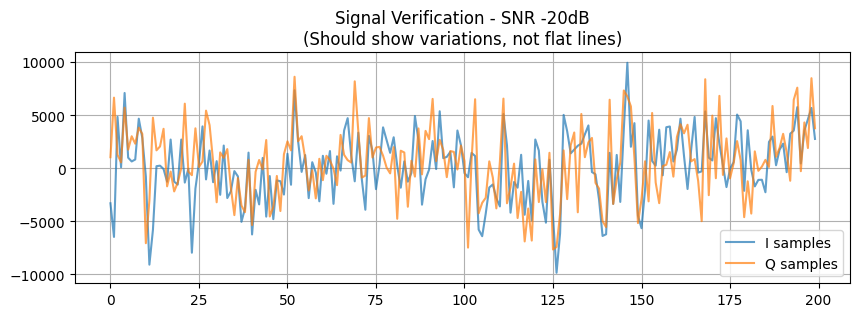

GOOD: Signal has proper variations
Saved: Final_-20dB.dat (122.07 MB)

 Generating Final_-15dB.dat...
Verifying Final_-15dB.dat...
    Std Dev: 6700.3
    Unique values: 45885
    Data range: -31354 to 30495


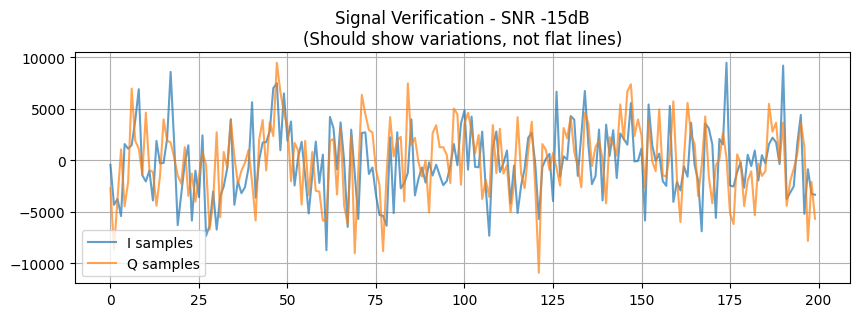

GOOD: Signal has proper variations
Saved: Final_-15dB.dat (122.07 MB)

 Generating Final_-10dB.dat...
Verifying Final_-10dB.dat...
    Std Dev: 6763.6
    Unique values: 45961
    Data range: -31771 to 30182


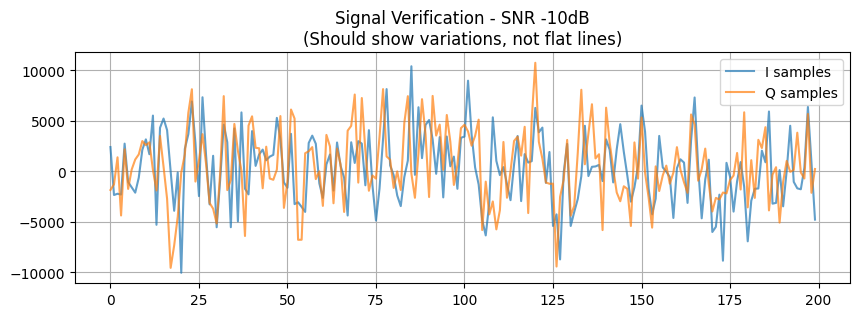

GOOD: Signal has proper variations
Saved: Final_-10dB.dat (122.07 MB)

 Generating Final_-5dB.dat...
Verifying Final_-5dB.dat...
    Std Dev: 6958.7
    Unique values: 45973
    Data range: -31419 to 30440


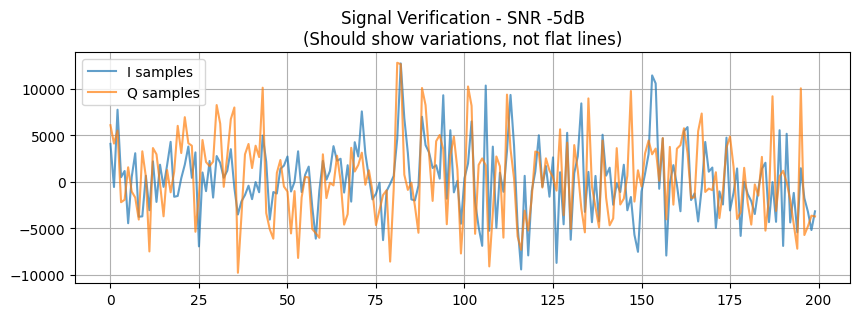

GOOD: Signal has proper variations
Saved: Final_-5dB.dat (122.07 MB)

 Generating Final_0dB.dat...
Verifying Final_0dB.dat...
    Std Dev: 7548.5
    Unique values: 46660
    Data range: -30684 to 32322


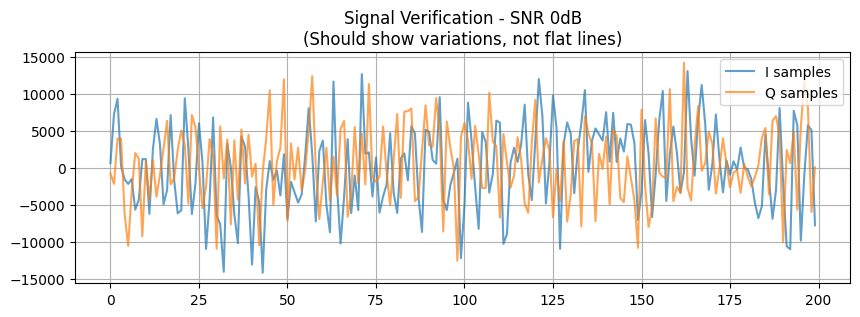

GOOD: Signal has proper variations
Saved: Final_0dB.dat (122.07 MB)

 Generating Final_5dB.dat...
Verifying Final_5dB.dat...
    Std Dev: 9162.5
    Unique values: 62264
    Data range: -32768 to 32767


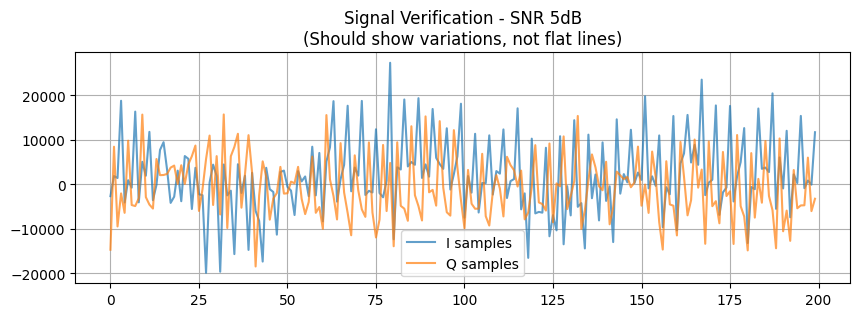

GOOD: Signal has proper variations
Saved: Final_5dB.dat (122.07 MB)

FIXED .dat FILES GENERATED!
Files created:
   📄 Final_-20dB.dat (125000.0 KB)
   📄 Final_-15dB.dat (125000.0 KB)
   📄 Final_-10dB.dat (125000.0 KB)
   📄 Final_-5dB.dat (125000.0 KB)
   📄 Final_0dB.dat (125000.0 KB)
   📄 Final_5dB.dat (125000.0 KB)
paper_accurate_metadata.json
Check the plots above - should show WAVEFORMS not flat lines!


In [16]:
# Test with a small dataset first
print("Generating test files (small size for verification)...")
generated_files = generate_paper_accurate_dat_files()

# Create paper-accurate metadata
metadata = {
    "paper_reference": "SCM-GNN: A Graph Neural Network-Based Multi-Antenna Spectrum Sensing",
    "section": "V-A1 Simulation Setting",
    "exact_parameters": {
        "M": 8,
        "num_symbols": 100,
        "samples_per_symbol": 8,
        "symbol_rate": "1 MHz",
        "modulation": "QPSK",
        "rolloff_factor": 0.5,
        "filter_span": 4,
        "correlation_coeff": 0.5,
        "pulse_shaping": "Root Raised Cosine"
    },
    "notes": "FIXED VERSION - Proper RRC filtering and scaling"
}

with open("accurate_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("\n" + "=" * 60)
print("FIXED .dat FILES GENERATED!")
print("=" * 60)
print("Files created:")
for file in generated_files:
    file_size = os.path.getsize(file) / 1024
    print(f"   📄 {file} ({file_size:.1f} KB)")
print("paper_accurate_metadata.json")
print("Check the plots above - should show WAVEFORMS not flat lines!")

Downloading the files

In [17]:
#Download all at once
from google.colab import files
import zipfile
import os

# Create a zip file with all .dat files
def create_and_download_zip():
    print("Creating download package...")

    zip_filename = "scm_gnn_dataset.zip"

    with zipfile.ZipFile(zip_filename, 'w') as zipf:
        files_to_zip = [
            "paper_accurate_snr_-20dB.dat",
            "paper_accurate_snr_-15dB.dat",
            "paper_accurate_snr_-10dB.dat",
            "paper_accurate_snr_-5dB.dat",
            "paper_accurate_metadata.json"
        ]

        for file in files_to_zip:
            if os.path.exists(file):
                zipf.write(file)
                print(f"Added {file} to zip")
            else:
                print(f"{file} not found")

    # Download the zip
    print(f"Downloading {zip_filename}...")
    files.download(zip_filename)
    print("Download complete! Check your downloads folder.")

# Run the one-click download
create_and_download_zip()

Creating download package...
paper_accurate_snr_-20dB.dat not found
paper_accurate_snr_-15dB.dat not found
paper_accurate_snr_-10dB.dat not found
paper_accurate_snr_-5dB.dat not found
paper_accurate_metadata.json not found


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download complete! Check your downloads folder.
